In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = sns.load_dataset("flights")

In [3]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [4]:
df.shape

(144, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [6]:
df.describe()

,year,passengers
count,144.000000,144.000000
mean,1954.500000,280.298611
std,3.464102,119.966317
min,1949.000000,104.000000
25%,1951.750000,180.000000
50%,1954.500000,265.500000
75%,1957.250000,360.500000
max,1960.000000,622.000000


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
year,0
month,0
passengers,0


In [9]:
df

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [10]:
df['year'].unique()

array([1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960])

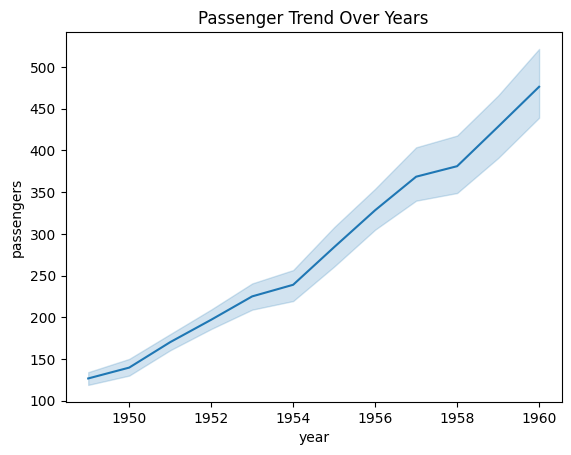

In [12]:
sns.lineplot(
    x='year',
    y='passengers',
    data=df
)

plt.title('Passenger Trend Over Years')
plt.show()

Passenger traffic shows a steady increase from 1949 to 1960.

In [15]:
df.groupby('year')['passengers'].sum().reset_index()



,year,passengers
0,1949,1520
1,1950,1676
2,1951,2042
3,1952,2364
4,1953,2700
5,1954,2867
6,1955,3408
7,1956,3939
8,1957,4421
9,1958,4572


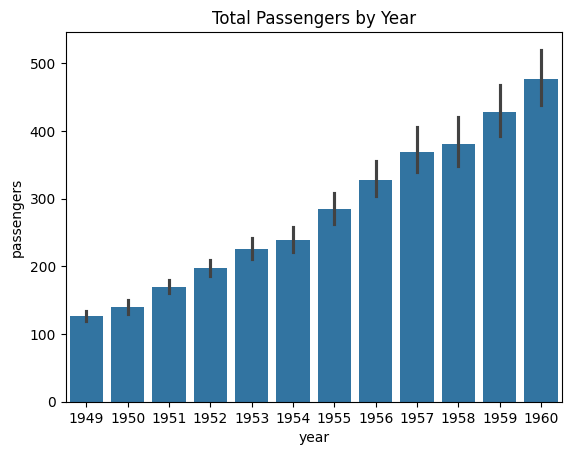

In [16]:
sns.barplot(
    x='year',
    y='passengers',
    data=df
)

plt.title('Total Passengers by Year')
plt.show()

In [18]:
df.groupby('month')['passengers'].mean().reset_index()


,month,passengers
0,Jan,241.750000
1,Feb,235.000000
2,Mar,270.166667
3,Apr,267.083333
4,May,271.833333
5,Jun,311.666667
6,Jul,351.333333
7,Aug,351.083333
8,Sep,302.416667
9,Oct,266.583333


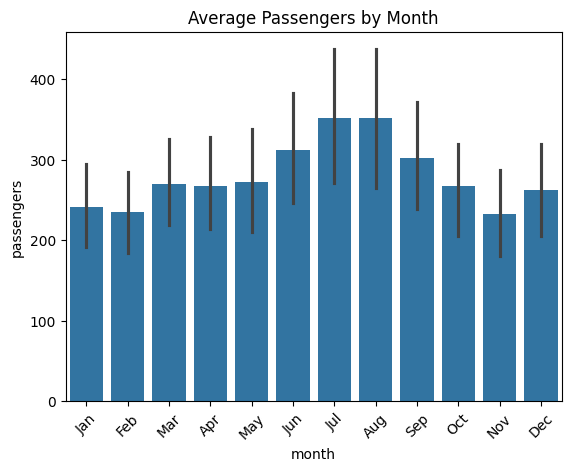

In [19]:
sns.barplot(
    x='month',
    y='passengers',
    data=df
)

plt.title('Average Passengers by Month')
plt.xticks(rotation=45)
plt.show()

In [28]:
pivot = df.pivot(index='month', columns='year', values='passengers')
pivot

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


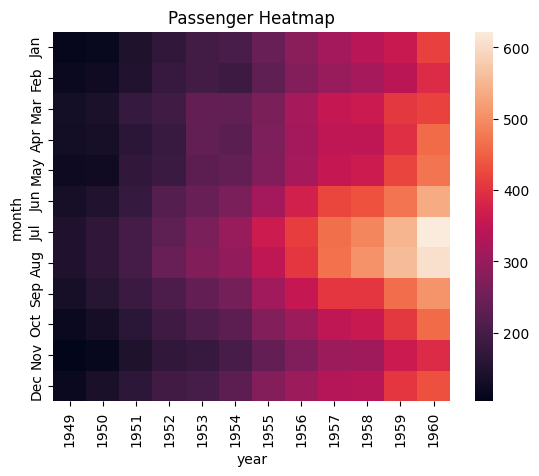

In [27]:
sns.heatmap(pivot)
plt.title('Passenger Heatmap')
plt.show()

Look for:

Darker colors = more passengers
Growth across years
Peak months

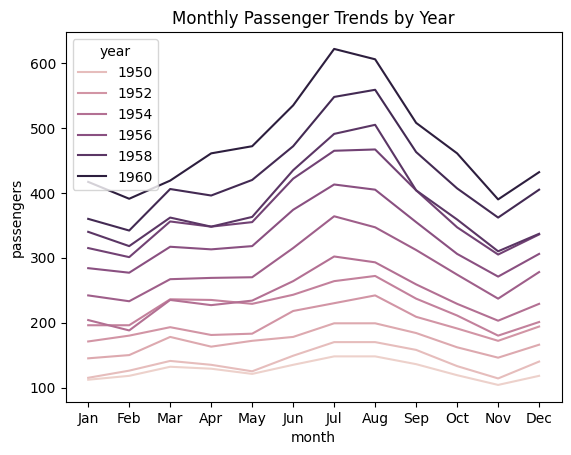

In [29]:
sns.lineplot(
    x=df['month'],
    y=df['passengers'],
    hue=df['year'],

)

plt.title('Monthly Passenger Trends by Year')
plt.show()